# EDA — SECOM 良率資料

這份 notebook 只做一件事：**找出會決定後續所有建模決策的資料事實**。

跑之前先執行 `python scripts/01_build_data.py`。

In [1]:
# 讓 notebook 不管從哪個目錄開啟都能跑：往上找到含有 secom/ 的那一層
import sys, pathlib
root = next(d for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (d / 'secom').is_dir())
sys.path.insert(0, str(root))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from secom import config as cfg_mod, data as data_mod

cfg = cfg_mod.load()
df = data_mod.load_processed(cfg)
feats = data_mod.feature_cols(df)
print(df.shape, '特徵數', len(feats))

(1567, 592) 特徵數 590


## 1. 不平衡有多嚴重

先確認 accuracy 為什麼是禁用字。

In [2]:
n_fail = int(df['fail'].sum())
print(f'fail {n_fail} / {len(df)} = {n_fail / len(df):.2%}')
print(f'不平衡比 1:{(len(df) - n_fail) / n_fail:.1f}')
print()
print(f'全部猜 pass 的 accuracy = {1 - n_fail / len(df):.2%}')
print('^ 這就是為什麼本專題全程不用 accuracy')

fail 104 / 1567 = 6.64%
不平衡比 1:14.1

全部猜 pass 的 accuracy = 93.36%
^ 這就是為什麼本專題全程不用 accuracy


## 2. 最關鍵的發現：良率隨時間漂移

**這一張圖決定了整個專題的切分策略。**

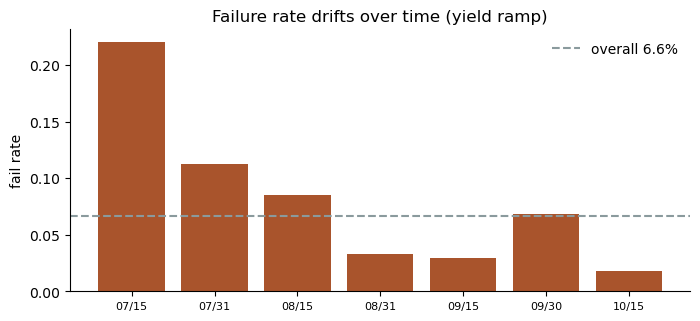

,size,sum,mean
ts,,,
2008-07-15,59,13,0.220339
2008-07-31,142,16,0.112676
2008-08-15,399,34,0.085213
2008-08-31,246,8,0.032520
2008-09-15,341,10,0.029326
2008-09-30,324,22,0.067901
2008-10-15,56,1,0.017857


In [3]:
g = df.set_index('ts')['fail'].resample('SME').agg(['size', 'sum', 'mean'])

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(range(len(g)), g['mean'], color='#A9542C')
ax.set_xticks(range(len(g)))
ax.set_xticklabels([d.strftime('%m/%d') for d in g.index], fontsize=8)
ax.axhline(df['fail'].mean(), ls='--', color='#8A9A9D',
           label=f"overall {df['fail'].mean():.1%}")
ax.set_ylabel('fail rate')
ax.set_title('Failure rate drifts over time (yield ramp)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.show()
g

fail 率從 22% 一路降到 1.8%。三個直接後果：

1. **不能隨機切分。** 早期高失效批次會同時出現在 train 和 test，模型只要學會「這是早期批次」就能拿高分，上線後崩掉。
2. **驗證集的 fail 數會很少**（實際只有 11 個），任何在 val 上估的東西都不穩。
3. **絕對機率門檻不耐用**，因為它綁在某個時期的基準率上 —— 這是後面要做分位數策略的理由。

## 3. 資料有多髒

缺值總格數 41,951 (4.54%)
零變異欄位 116
缺值過半的欄位 28


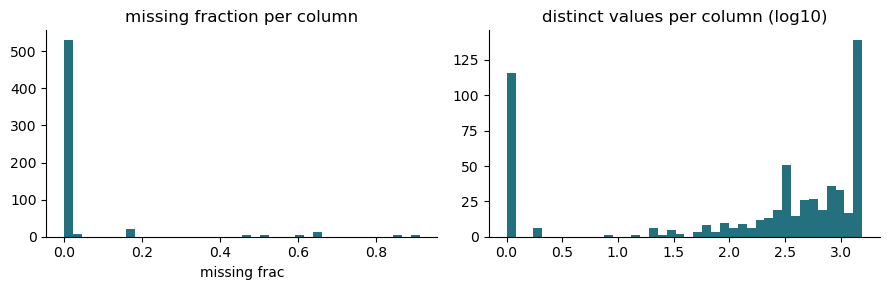

In [4]:
X = df[feats]
miss = X.isna().mean()
nun = X.nunique(dropna=True)

print(f'缺值總格數 {int(X.isna().sum().sum()):,} ({X.isna().sum().sum() / X.size:.2%})')
print(f'零變異欄位 {int((nun <= 1).sum())}')
print(f'缺值過半的欄位 {int((miss > 0.5).sum())}')

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(miss, bins=40, color='#25707F')
ax[0].set_title('missing fraction per column')
ax[0].set_xlabel('missing frac')
ax[1].hist(np.log10(nun.replace(0, np.nan)), bins=40, color='#25707F')
ax[1].set_title('distinct values per column (log10)')
for a in ax:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4. 缺值本身帶訊息嗎

如果某欄的缺值與 fail 相關，那麼「硬填中位數」會把訊息抹掉。這是主模型不做填補的理由。

In [5]:
rows = []
for c in feats:
    m = X[c].isna()
    if 0.02 < m.mean() < 0.98:
        rows.append({
            'feature': c,
            'missing_frac': m.mean(),
            'fail_when_missing': df.loc[m, 'fail'].mean(),
            'fail_when_present': df.loc[~m, 'fail'].mean(),
        })

mv = pd.DataFrame(rows)
mv['gap'] = (mv['fail_when_missing'] - mv['fail_when_present']).abs()
print(f'可分析的欄位 {len(mv)} 個，整體 fail 率 {df["fail"].mean():.2%}')
mv.nlargest(10, 'gap').round(4)

可分析的欄位 60 個，整體 fail 率 6.64%


,feature,missing_frac,fail_when_missing,fail_when_present,gap
3,f089,0.0325,0.0196,0.0679,0.0483
4,f090,0.0325,0.0196,0.0679,0.0483
12,f224,0.0325,0.0196,0.0679,0.0483
13,f225,0.0325,0.0196,0.0679,0.0483
23,f362,0.0325,0.0196,0.0679,0.0483
24,f363,0.0325,0.0196,0.0679,0.0483
30,f496,0.0325,0.0196,0.0679,0.0483
31,f497,0.0325,0.0196,0.0679,0.0483
0,f072,0.5067,0.0453,0.0880,0.0426
1,f073,0.5067,0.0453,0.0880,0.0426


缺值與 fail 率有落差的欄位確實存在 —— 「這個站點當時沒量到」本身就是訊號。所以 LightGBM 路徑刻意保留 NaN，讓模型自己學缺值往哪一邊走；只有線性 baseline 才做中位數填補（因為它不吃 NaN）。

## 5. 單一特徵能分得多開

先確認一下：有沒有哪個感測器單看就能分開 pass / fail？

In [6]:
from scipy import stats

rows = []
for c in feats:
    a = X.loc[df['fail'] == 1, c].dropna()
    b = X.loc[df['fail'] == 0, c].dropna()
    if len(a) > 20 and len(b) > 20 and (a.std() > 0 or b.std() > 0):
        t, p = stats.ttest_ind(a, b, equal_var=False)
        rows.append({'feature': c, 't': t, 'p': p})

ts = pd.DataFrame(rows).sort_values('p')
n_sig = int((ts['p'] < 0.01).sum())
print(f'檢定了 {len(ts)} 個特徵，p < 0.01 的有 {n_sig} 個')
print('注意：590 次檢定有多重比較問題，這裡只當探索，不當結論')
ts.head(10)

檢定了 466 個特徵，p < 0.01 的有 35 個
注意：590 次檢定有多重比較問題，這裡只當探索，不當結論


,feature,t,p
121,f129,5.706101,6.837903e-08
54,f059,5.475246,2.627138e-07
95,f103,5.287106,6.059669e-07
26,f028,-4.459882,1.876330e-05
262,f316,-4.071100,8.276539e-05
117,f125,-4.056093,8.630872e-05
122,f130,3.932644,1.353388e-04
103,f111,-4.204413,1.476038e-04
114,f122,-3.833813,1.967083e-04
104,f112,3.700504,2.301250e-04


沒有任何單一感測器能乾淨分開兩類。訊號是**弱且分散**的 —— 這解釋了為什麼最終 ROC-AUC 只有 0.69，也解釋了為什麼**決策層比模型層更重要**：在排序能力有限的情況下，能賺到錢的關鍵是把成本不對稱用對。

## 6. 時序切分後的樣貌

In [7]:
s = data_mod.time_split(df, cfg)
s.summary()

,split,n,n_fail,fail_rate,from,to
0,train,940,76,0.080851,2008-07-19 11:55:00,2008-09-20 05:34:00
1,val,313,11,0.035144,2008-09-20 06:08:00,2008-10-02 19:25:00
2,test,314,17,0.054140,2008-10-02 20:54:00,2008-10-17 06:07:00


val 只有 11 個 fail。這個數字是後面兩個方法論決策的直接原因：

- 樹的棵數改用 **train 內部的擴張窗 CV** 決定，不用 val 早停（第一版早停在第 1 棵樹）
- 機率校準改用 **train OOF + val**，把正樣本從 11 拉到 55

細節見 `README.md` 的「方法論：三個踩過的坑」。

---

下一步：`python scripts/02_train.py`